# Final Project.
# Student Performance Prediction Using Machine Learning
## Soad Abdallah Alastal.
## 2320222560

### Introduction & Problem Statement .
### Introduction:
#### Predicting student performance is one of the most important applications of machine learning in education. Educational institutions collect student data, such as attendance, study hours, and past grades. Machine learning techniques can analyze this data and help predict students' academic performance. These predictions help teachers identify students who may need additional support.
### Problem Statement:
#### The goal of this project is to build a regression model using machine learning that predicts a student's success or failure based on several factors, namely study hours, attendance, and past academic performance. We will apply two machine learning algorithms: Linear Regression and Decision Tree Regression, and compare them to determine which provides better prediction performance.

### Dataset Description:
#### The data used in this project consists of **student performance factors**. It includes **6607 students**.The dataset contains both numerical and categorical characteristics. Key characteristics include:Study hours,Attendance,Previous grades,Sleep hours,Motivation level,Internet access,Family income,Teacher quality,School type,Physical activity,Gender.
#### The target variable in this project is Exam_Score. This variable will be used to predict students' exam scores using regression models. The remaining features will be used as input variables for training and evaluating the models. The remaining characteristics will be used as input variables to train and evaluate machine learning models.
#### I obtained the dataset from **Kaggle**,contains 6,607 student records.

### Data Processing:
#### Before building any model, I must prepare the dataset. This stage includes loading the dataset, verifying its structure, identifying missing values, manipulating categorical variables, detecting outliers, and preparing the data for training. These steps help improve data quality and model performance.

### Data Preprocessing:

In [ ]:
# First, we imported the Pandas and NumPy libraries.We used Pandas to read the dataset file, and NumPy to handle missing values and perform mathematical operations.
import pandas as pd
import numpy as np

In [ ]:
# Reading data.
df = pd.read_csv("StudentPerformanceFactors.csv")
# We displayed the first five rows of the dataset.
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [ ]:
# We used Info to find out information about the data I have, for example, each column, its type, how many columns are of the "float" type, how many are of the "int" type, how many rows and columns there are, and whether there are any empty values ​​in the columns.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 non-null   obje

In [ ]:
# Here, we checked the shape of the dataset to see how many rows and columns it contains.Here, we checked the shape of the dataset to see how many rows and columns it contains.
df.shape

(6607, 20)

In [ ]:
# Statistical description.
df.describe()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


In [ ]:
# check for missing values.
df.isnull().sum()

,0
Hours_Studied,0
Attendance,0
Parental_Involvement,0
Access_to_Resources,0
Extracurricular_Activities,0
Sleep_Hours,0
Previous_Scores,0
Motivation_Level,0
Internet_Access,0
Tutoring_Sessions,0


### Missing Values:
#### When we examined the missing values, we found them in three columns:
##### 1.Teacher Quality: 78 missing values.
##### 2.Parents' Education Level: 90 missing values.
##### 3.Distance from Home: 67 missing values.
#### Now I want to address the missing values ​​in the object columns. I used the **mode** (the most frequent value within the column) to fill in the missing values. Each missing value is replaced with the most common value in its column.

In [ ]:
df["Teacher_Quality"].fillna(df["Teacher_Quality"].mode()[0], inplace=True)
df["Parental_Education_Level"].fillna(df["Parental_Education_Level"].mode()[0], inplace=True)
df["Distance_from_Home"].fillna(df["Distance_from_Home"].mode()[0], inplace=True)

/tmp/ipykernel_3517/4006623996.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Teacher_Quality"].fillna(df["Teacher_Quality"].mode()[0], inplace=True)
/tmp/ipykernel_3517/4006623996.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(

In [ ]:
df.isnull().sum()

,0
Hours_Studied,0
Attendance,0
Parental_Involvement,0
Access_to_Resources,0
Extracurricular_Activities,0
Sleep_Hours,0
Previous_Scores,0
Motivation_Level,0
Internet_Access,0
Tutoring_Sessions,0


In [ ]:
# Check for duplicate values.
df.duplicated().sum()

np.int64(0)

##### Some columns in the dataset contain text values. Therefore, I converted these categorical columns into numerical values using Label Encoding before training the model.

In [ ]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
# select_dtypes(include="object"):This means that each column is an object; I need to create a number converter.
for columns in df.select_dtypes(include="object").columns:
    df[columns] = label_encoder.fit_transform(df[columns])

In [ ]:
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,1,0,0,7,73,1,1,0,1,2,1,2,3,0,1,2,1,67
1,19,64,1,2,0,8,59,1,1,2,2,2,1,0,4,0,0,1,0,61
2,24,98,2,2,1,7,91,2,1,2,2,2,1,1,4,0,2,2,1,74
3,29,89,1,2,1,8,98,2,1,1,2,2,1,0,4,0,1,1,1,71
4,19,92,2,2,1,6,65,2,1,3,2,0,1,1,4,0,0,2,0,70


#### Now I need to create a boxplot to see the outliers.
##### The outliers that appeared are normal values ​​and not the result of a data error.
##### Hours_Studied This is the number of hours a student spent studying. Why are there outliers? Because some students studied significantly more or fewer hours than others.Why didn't I delete them? Because they represent a genuine difference between students and are not a data entry error, so I kept them.
##### Tutoring_Sessions Why are there outliers? Some students received more tutoring sessions than most students.Why weren't they deleted? Because variations in the number of tutoring sessions are normal and can affect student performance, so they weren't deleted.
##### Exam_Score :This is the final score a student receives on the exam.Why are there outliers? Some students received very high or very low scores compared to the rest of the students.Why didn't I delete them? Because these scores are real and represent student performance. If I deleted them, I might lose important information.

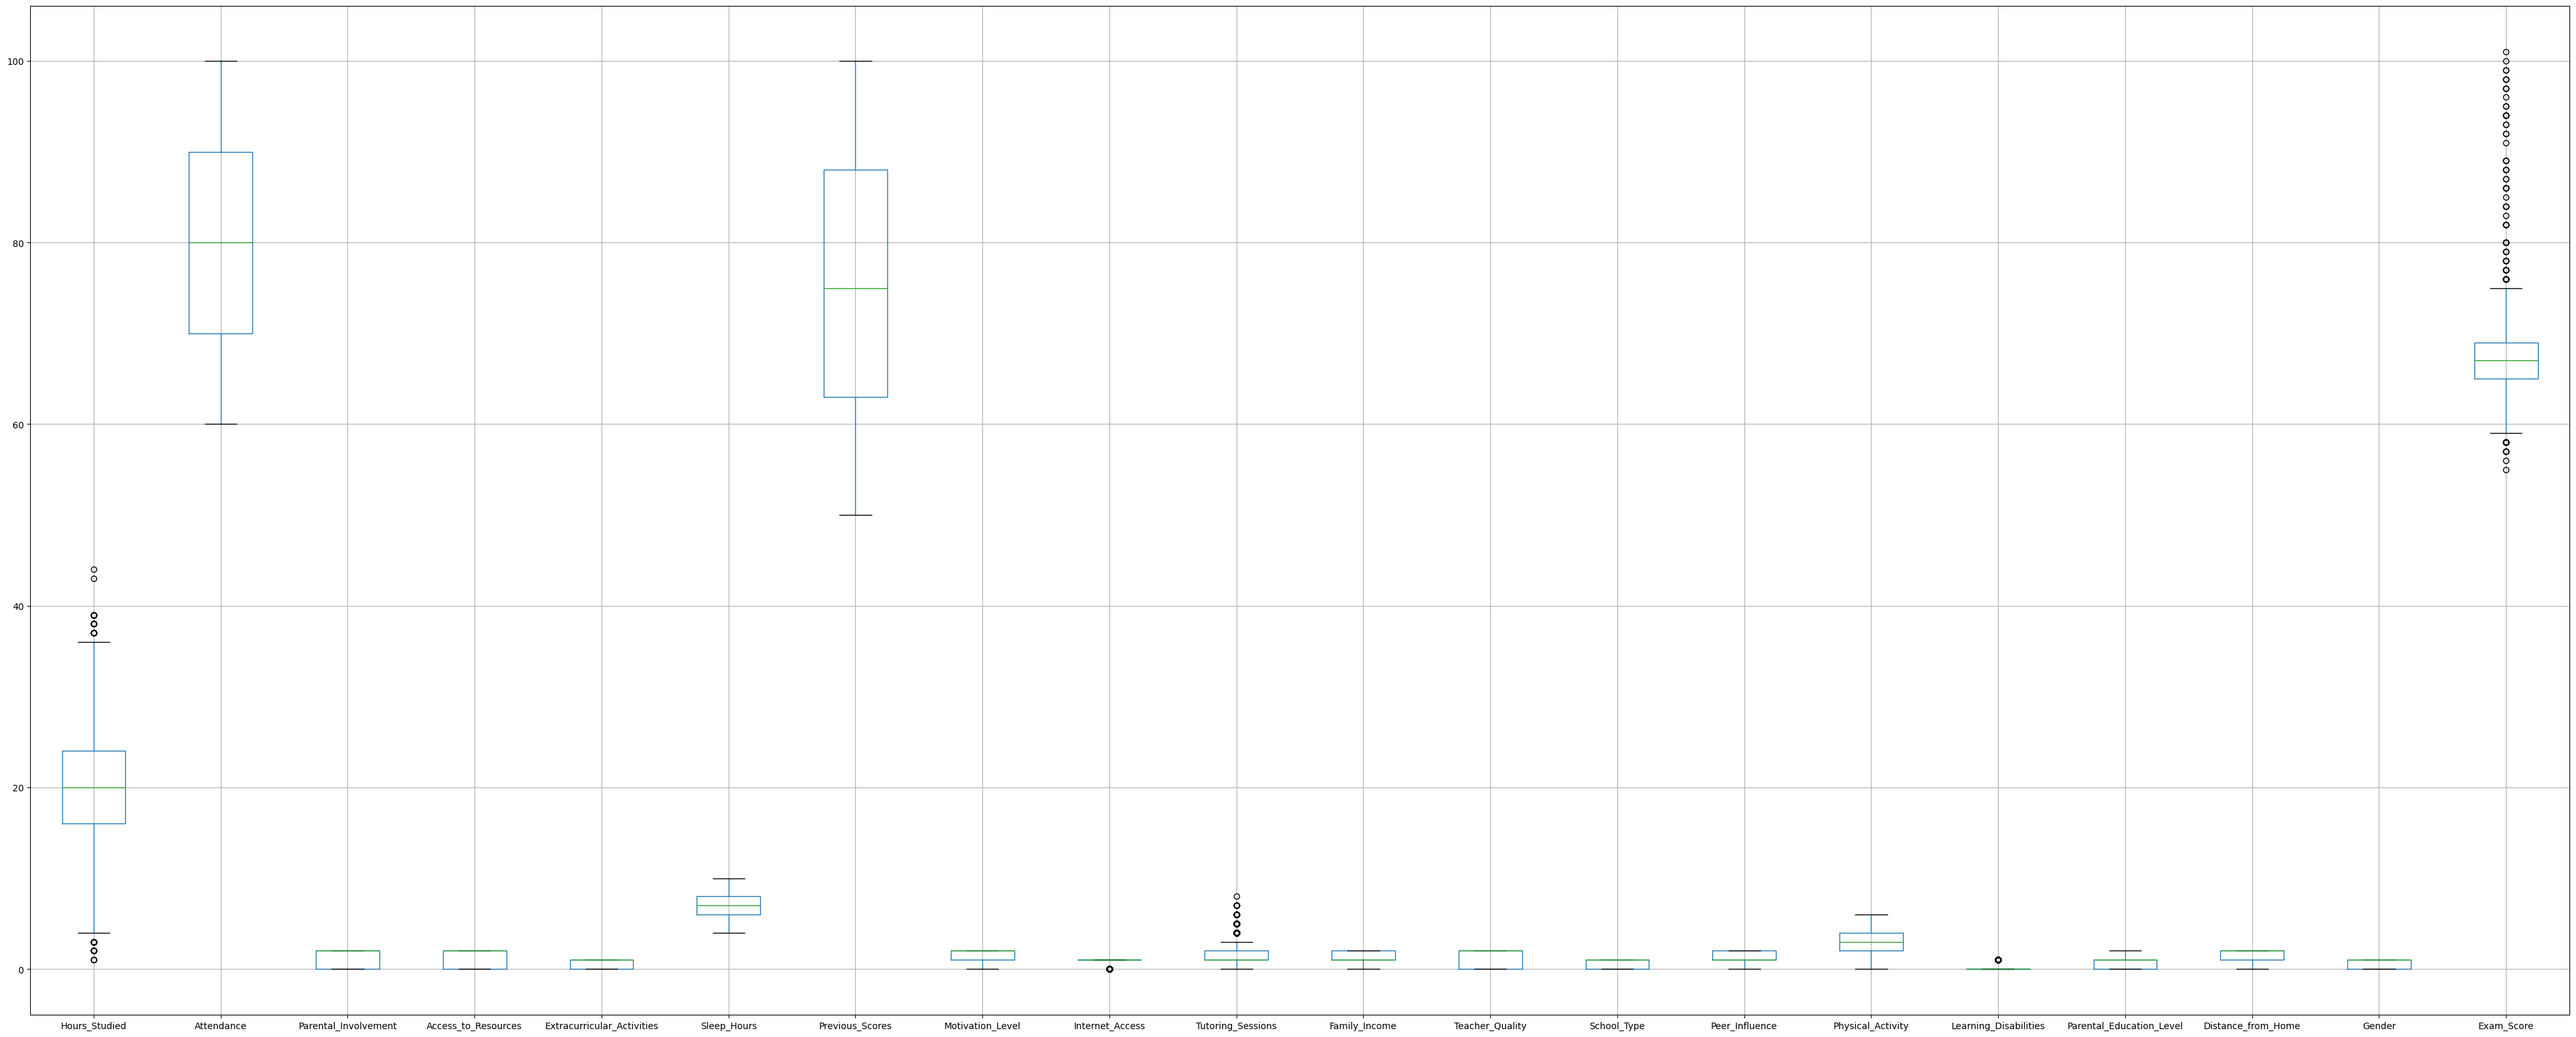

In [ ]:
import matplotlib.pyplot as plt
df.boxplot(figsize=(50,20))
plt.show()

##### Feature Engineering :The dataset already contains features useful for predicting student performance. Therefore, there was no need to engineer additional features.

### Exploratory Data Analysis (EDA):
#### ● Perform statistical and visual EDA using:
##### ○ Matplotlib
##### ○ Seaborn

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

#### ○ Distribution plots

##### Most students' grades were between 65 and 70. However, there were a few students who received very low or very high grades in the exams.

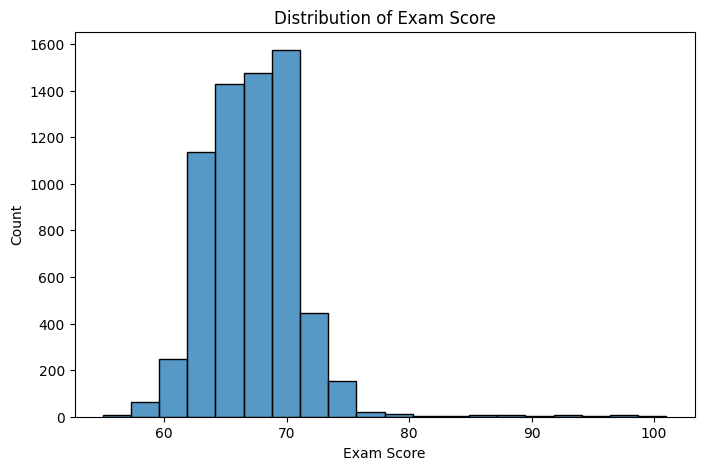

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df["Exam_Score"], bins=20)
plt.title("Distribution of Exam Score")
plt.xlabel("Exam Score")
plt.ylabel("Count")
plt.show()

##### Most students spent between 15 and 25 hours studying, while a few studied much fewer or much more hours.

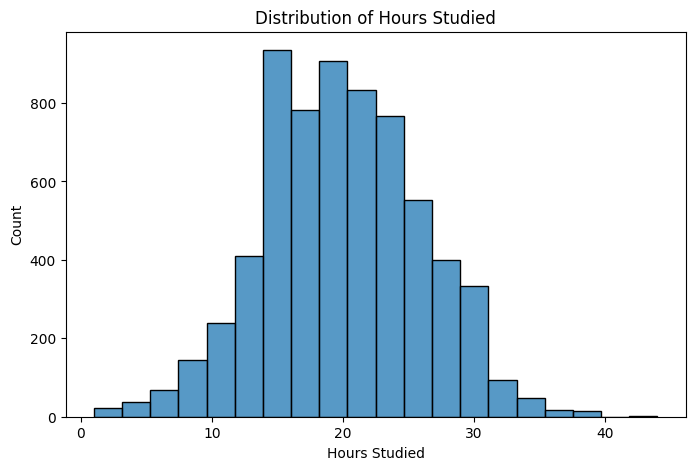

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df["Hours_Studied"], bins=20)
plt.title("Distribution of Hours Studied")
plt.xlabel("Hours Studied")
plt.ylabel("Count")
plt.show()

#### ○ Correlation analysis.
##### I created a correlation matrix to measure the relationship between all the variables in the dataset. This helps me understand which traits have the strongest influence on the target variable (exam score).
##### The strongest factors positively correlated with exam score are attendance (0.58) and study hours (0.45). This means that students who attend lectures regularly and study for longer hours tend to achieve higher exam scores.

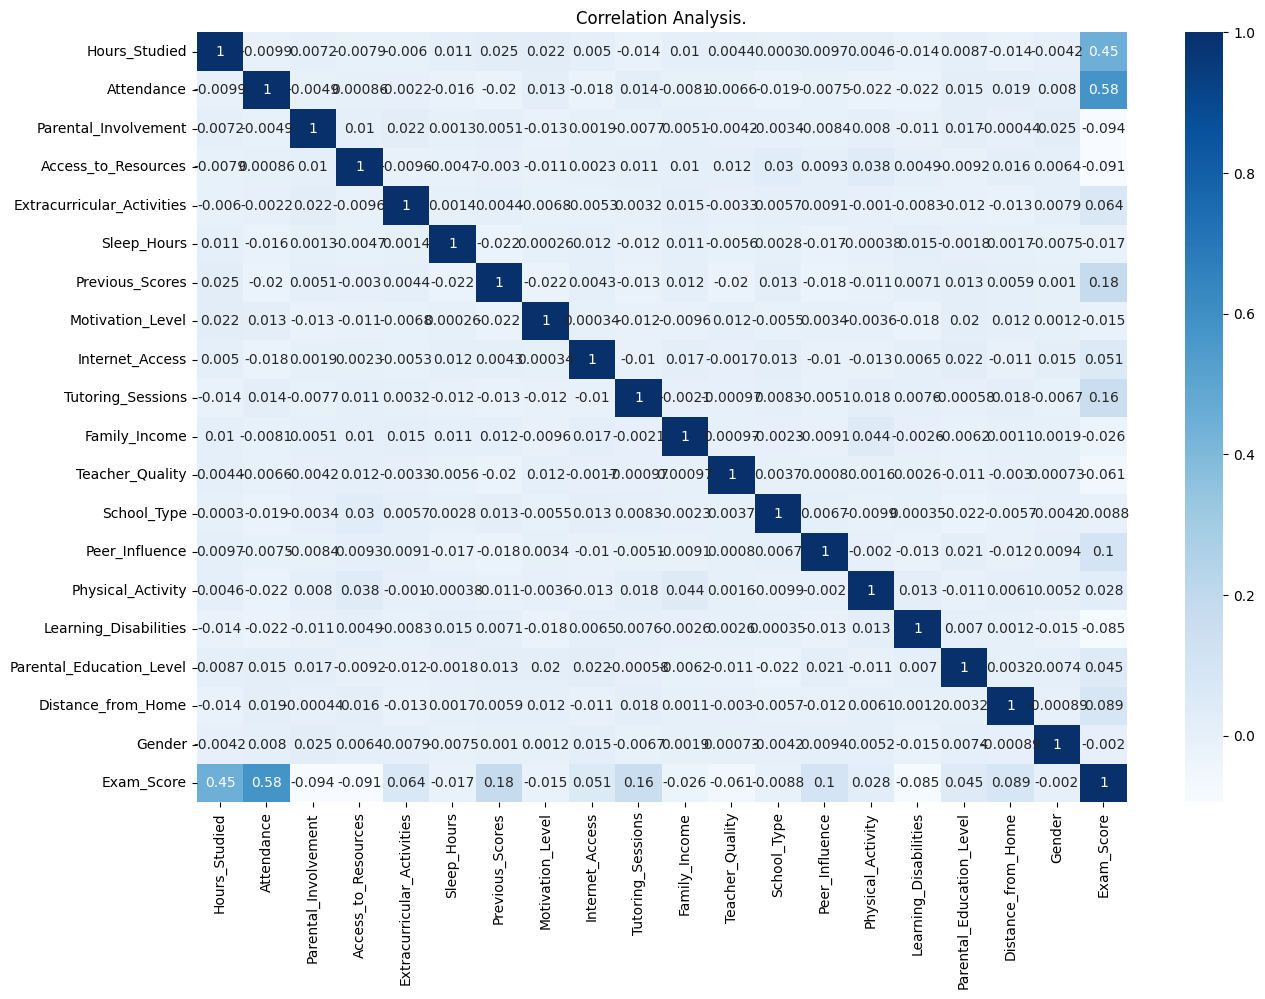

In [ ]:
plt.figure(figsize=(15,10))
# annot=True shows correlation numbers, cmap="Blues" changes the heatmap colors.
sns.heatmap(df.corr(), annot=True, cmap="Blues")
plt.title("Correlation Analysis.")
plt.show()

#### ○ Feature-target relationships.
##### I created a diagram to illustrate the relationship between the number of study hours and exam scores. This diagram helps me understand whether increasing study hours leads to higher exam scores.
##### There is a direct relationship between the number of study hours and exam scores. Students who study longer hours tend to get higher exam scores.

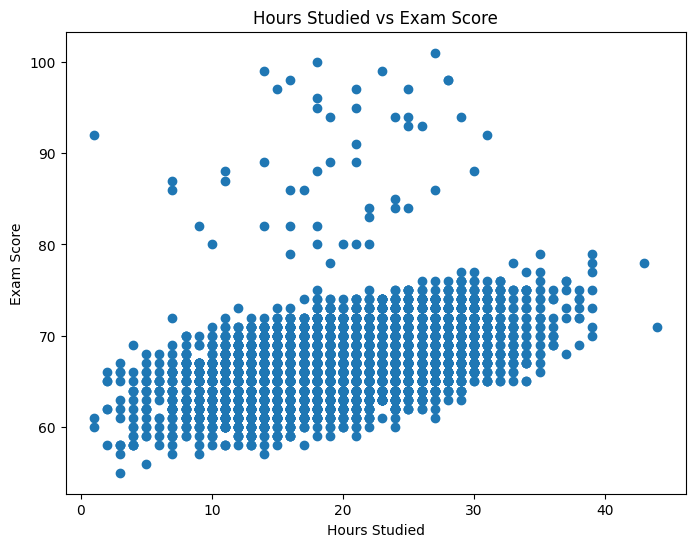

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(df["Hours_Studied"], df["Exam_Score"])
plt.title("Hours Studied vs Exam Score")
plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")
plt.show()

##### We want to examine the relationship between attendance and exam scores. Students with higher attendance generally get better exam scores.
##### The scatter plot shows a positive correlation between attendance and exam scores. Students who consistently attend exams achieve higher scores.

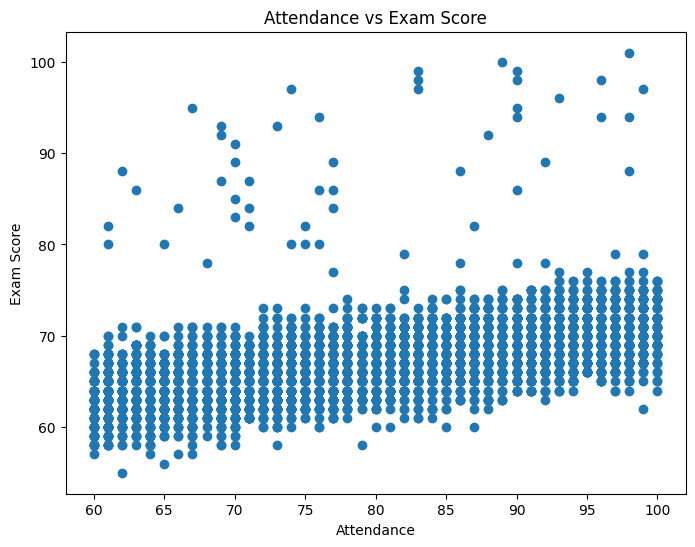

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(df["Attendance"], df["Exam_Score"])
plt.title("Attendance vs Exam Score")
plt.xlabel("Attendance")
plt.ylabel("Exam Score")
plt.show()

### Model Implementation
####● Supervised Learning (Choose at least TWO models):
##### ○ Linear Regression.
##### ○ Decision Trees

### Model Training & Evaluation
#### ● Split data into training and testing sets.
##### Now I need to prepare the data to train the machine learning models. First, I will separate the input characteristics (X) from the target variable (y). I will use these characteristics to predict the exam score.

In [ ]:
X = df.drop("Exam_Score", axis=1)
y = df["Exam_Score"]

##### I divided the dataset into two sets: training and test. The training data is used to train the models, and the test data is used to evaluate the model's performance.

In [ ]:
from sklearn.model_selection import train_test_split
# test_size=0.2 means 80% for training and 20% for testing.
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=42)

#### Linear regression is the first model used in this project. This model attempts to find a linear relationship between the input characteristics and the target variable, which is the exam score.

### Use Cross Validation:
##### I used cross-validation to test the model on different parts of the dataset.

In [ ]:
from sklearn.model_selection import cross_val_score
#cv=5: We divided the data into five parts and tried it five times.
linear_scores = cross_val_score(linear_model, X, y, cv=5, scoring="r2")
print("Linear Regression Cross Validation Scores:", linear_scores)
print("Average R2 Score:", linear_scores.mean())
# The model achieved an average R² score of 0.65, which means that it performed well.

Linear Regression Cross Validation Scores: [0.55747493 0.64721503 0.63465934 0.65097326 0.7620576 ]
Average R2 Score: 0.6504760310494632


### Apply appropriate evaluation metrics, such as:
#### ○ Regression: MSE, RMSE, R²

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
linear_prediction = linear_model.predict(X_test)

In [ ]:
mse = mean_squared_error(y_test, linear_prediction)
rmse = np.sqrt(mse)
# Calculate the R² value to determine how well the model is performing.
r2 = r2_score(y_test, linear_prediction)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

# The smaller the RMSE value, the closer the forecasts are to the actual values.
# The R² value is relatively high, which means that the model is performing well.

MSE: 4.3992755391709535
RMSE: 2.097445002657031
R2 Score: 0.6887688020307757


#### Now I will train a decision tree regression model to predict the exam score.

In [ ]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score
tree_model = DecisionTreeRegressor(random_state=42)
tree_model.fit(X_train, y_train)
tree_prediction = tree_model.predict(X_test)

##### I evaluated the Decision Tree model using MSE, RMSE, and R² to measure its performance.

In [ ]:
mse = mean_squared_error(y_test, tree_prediction)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, tree_prediction)
print("MSE:", mse)
print("Decision Tree RMSE:", rmse)
print("Decision Tree R2 Score:", r2)
# MSE: The prediction error is relatively high.
# RMSE: The model predictions differ from the actual scores by about 3.3 marks.
# R²: The model performance is weak because the R² score is low.

MSE: 10.877458396369137
Decision Tree RMSE: 3.298099209600757
Decision Tree R2 Score: 0.23046320299356693


#### I used cross-validation to test the decision tree model on different parts of the dataset. This helps to make the evaluation more reliable.

In [ ]:
from sklearn.model_selection import cross_val_score
# cv=5 means the dataset is divided into five parts.
# The model is trained and tested five times.
tree_scores = cross_val_score(tree_model, X, y, cv=5, scoring="r2")
print("Decision Tree Cross Validation Scores:", tree_scores)
print("Average R2 Score:", tree_scores.mean())

# The average value of R² is low, so the model's performance is poor.
# The average value of R² is approximately 0.22, which means that the decision tree model is working poorly.

Decision Tree Cross Validation Scores: [0.2045601  0.29751068 0.12884052 0.27128932 0.18307721]
Average R2 Score: 0.21705556453497862


### Compare models and justify the final selection:
##### Linear regression showed better results than decision trees. It achieved a higher coefficient of determination (R²) and more accurate predictions, which is why I chose it as the final model.

### Model Interpretation
#### ● Explain model behavior and limitations.
##### First, we chose the Linear Regression model because it had the highest R² score. This model learns the relationship between the input features and the exam score using the training data. Then, it uses this relationship to predict the exam score of new students.However, the model has some limitations. It assumes that the relationship between the variables is linear. If the relationship is more complex or the data contains missing values or noise, the prediction accuracy may decrease.

#### ● Discuss potential real-world implications.
##### How can I benefit from my project in real life? Schools could use it to predict student grades, and it could also help me identify students who need extra support. Furthermore, it helps teachers monitor student performance and make better decisions.

### Advanced Features (Optional for Extra Marks)
#### ● Hyperparameter tuning (GridSearchCV)
##### I used GridSearchCV to test different settings for the Decision Tree model. This helps choose the best parameters and improve the model performance.

In [ ]:
# GridSearchCV tries all values ​​and chooses the best one.
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeRegressor

# max_deep means the depth of the tree.
# min_samples_split means the minimum number of data points that must be present for the tree to split.
params = {"max_depth": [3, 5, 7, 10],"min_samples_split": [2, 5, 10]}

grid_search = GridSearchCV(DecisionTreeRegressor(random_state=42),params,cv=5,scoring="r2")

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best R2 Score:", grid_search.best_score_)

Best Parameters: {'max_depth': 5, 'min_samples_split': 2}
Best R2 Score: 0.46558986498613375


### ● Model comparison visualization.
##### I compared the Linear Regression model with the Decision Tree model using their R² scores. This chart makes it easy to see which model performed better.

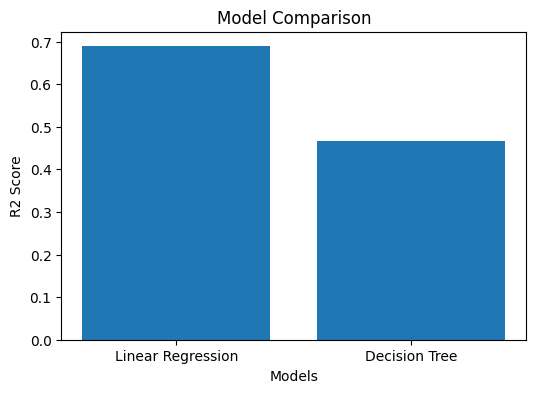

In [ ]:
import matplotlib.pyplot as plt

models = ["Linear Regression", "Decision Tree"]
# We used the values ​​we obtained:
scores = [0.6888, 0.4656]

plt.figure(figsize=(6,4))
plt.bar(models, scores)

plt.title("Model Comparison")
plt.xlabel("Models")
plt.ylabel("R2 Score")

plt.show()
# Linear Regression achieved the highest R² score.
# Therefore, it was selected as the final model.